### LLM error analysis by country
- IQR based error matrix:
    - accurate(0): LLM response in between 25th and 75th percentile of human distribution
    - over-estimate(1): LLM response above 75th percentile
    - under-estimate(-1): LLM response below 25th percentile

    

In [1]:
import pickle 
import textwrap 
import pandas as pd 
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

import statsmodels.formula.api as smf
from scipy.stats import zscore, pearsonr


In [2]:
# read country average data, get the countries and selected survey items
df_avg = pd.read_csv("../data/processed/wvs7_country_avg.csv").set_index('Country')
items = list(df_avg.columns) # select the same items for the following dataframes
all_countries = list(df_avg.index)
df_avg.shape

(66, 117)

In [ ]:
df_wvs = pd.read_csv("./data/wvs7_scaled.csv")[['Country'] + items].set_index('Country')
df_wvs.shape

(97220, 117)

In [ ]:
df_c2q = pd.read_csv('./data/Maps - code2question.csv')
df_c2q['question'] = df_c2q['s_category'] + ': ' + df_c2q['q_content']

In [ ]:
# LLM country representation
# make sure rows/countries and columns/items have consistent orders
df_gpt = pd.read_csv("./data/gpt_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]
df_claude = pd.read_csv("./data/claude_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]
df_deepseek = pd.read_csv("./data/deepseek_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries]

df_gpt.shape, df_claude.shape, df_deepseek.shape

((66, 117), (66, 117), (66, 117))

In [33]:
# LLM country representation
df_llm = df_gpt # df_gpt, df_claude, df_deepseek
llm_name = "GPT" # GPT, Claude, DeepSeek

### Visualize the LLM response within individual response distribution

In [ ]:
def check_item_distribution_byCtry_flip(df_llm, ctry, item_list):
    # for a given country, check the distribution of the given items (horizontal)
    data_by_item = [df_wvs.loc[ctry, item].dropna().values for item in item_list]

    code2q = df_c2q.set_index('code')['question'].to_dict()
    ylabels = [f"{item}\n{textwrap.fill(code2q.get(item, ''), width=40)}" for item in item_list]

    fig, ax = plt.subplots(figsize=(8, max(4, len(item_list) * 0.4)))
    ax.boxplot(data_by_item, positions=range(len(item_list)), widths=0.5,
               vert=False, showfliers=True,
               showmeans=True, meanline=True,
               flierprops=dict(marker='o', markersize=2, alpha=0.3),
               medianprops=dict(linewidth=0),
               meanprops=dict(color='orange', linewidth=1.5, linestyle='--'))

    # overlay the LLM's value for each item
    llm_values = df_llm.loc[ctry, item_list].values
    over_items  = {'F114C'}
    under_items = {'C001_01', 'E233B', 'E268'}
    dot_colors = ['red' if item in over_items else
                  'steelblue' if item in under_items else
                  'gold' for item in item_list]
    ax.scatter(llm_values, range(len(item_list)), color=dot_colors, edgecolor='black',
               marker='D', s=40, zorder=5)

    ax.set_yticks(range(len(item_list)))
    ax.set_yticklabels(ylabels, fontsize=12)
    ax.invert_yaxis()
    ax.set_xlabel('Item Response (value scaled to 0~1)', fontsize=14)
    
    legend_handles = [
        Line2D([0],[0], marker='D', color='w', markerfacecolor='gold',      markeredgecolor='black', markersize=8, label='Within Q1~Q3'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor='red',       markeredgecolor='black', markersize=8, label='Over-estimate (>Q3)'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor='steelblue', markeredgecolor='black', markersize=8, label='Under-estimate (<Q1)'),
    ]
    ax.legend(handles=legend_handles, fontsize=9, loc="upper left")
    plt.tight_layout()
    ax.set_title(f'{ctry}: LLM response \nwithin the distribution of individual responses', fontweight="bold")
    
    # plt.savefig('./mainfig/2A_distribution.pdf', dpi=300, bbox_inches='tight')
    plt.show()


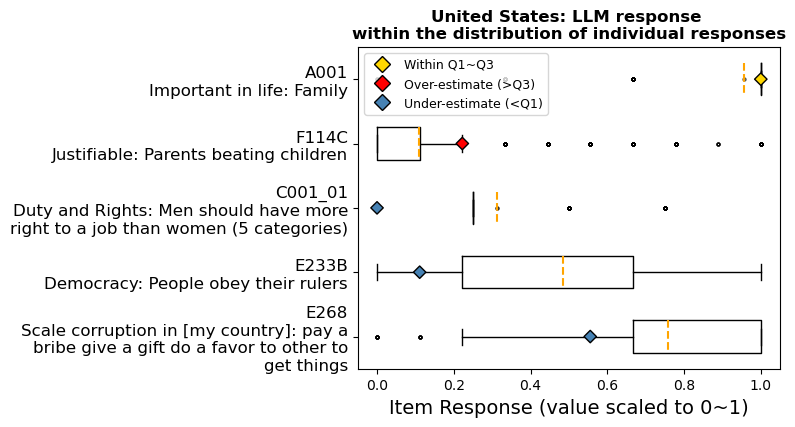

In [8]:
check_item_distribution_byCtry_flip(df_gpt, "United States", 
                               item_list=['A001','F114C','C001_01','E233B','E268'])

### Error matrix based on IQR
- for each (country, item) in df_wvs, rank the item values
- identify the 25% value and 75% value
- for LLM response, label each (country, item) as:
    - under-estimate (-1) if LLM < 25%
    - over-estimate (1) if LLM > 75%
    - accurate (0) if LLM within 25% and 75%

In [8]:
# df_iqr: for each (country, item), store [q25, q75] of the WVS individual response distribution
iqr_data = {}
for ctry in all_countries:
    df_ctry = df_wvs.loc[ctry]
    iqr_data[ctry] = {
        item: (df_ctry[item].quantile(0.25).round(2), df_ctry[item].quantile(0.75).round(2))
        for item in items
    }

df_iqr = pd.DataFrame(iqr_data).T.reindex(index=all_countries, columns=items)
df_iqr.round(3).head()

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Andorra,"(1.0, 1.0)","(0.67, 1.0)","(0.67, 1.0)","(0.0, 0.67)","(0.67, 1.0)","(0.0, 0.67)","(0.67, 1.0)","(0.75, 1.0)","(0.0, 0.5)","(0.0, 1.0)",...,"(0.67, 1.0)","(0.33, 0.67)","(0.33, 1.0)","(0.0, 0.0)","(0.0, 0.0)","(0.0, 0.0)","(0.0, 0.33)","(0.0, 1.0)","(0.0, 1.0)","(0.0, 0.0)"
Argentina,"(1.0, 1.0)","(0.67, 1.0)","(0.67, 1.0)","(0.33, 0.67)","(0.67, 1.0)","(0.33, 0.67)","(0.67, 1.0)","(0.5, 0.75)","(0.0, 0.5)","(0.0, 0.0)",...,"(0.33, 0.67)","(0.33, 0.67)","(0.0, 0.67)","(0.0, 0.0)","(0.0, 0.67)","(0.0, 0.0)","(0.0, 0.33)","(0.0, 1.0)","(0.0, 1.0)","(0.0, 0.0)"
Armenia,"(1.0, 1.0)","(0.67, 1.0)","(0.67, 1.0)","(0.0, 0.67)","(1.0, 1.0)","(0.67, 1.0)","(0.67, 1.0)","(0.5, 0.75)","(0.5, 1.0)","(0.0, 0.0)",...,"(0.33, 0.67)","(0.33, 1.0)","(0.67, 1.0)","(0.0, 0.0)","(0.0, 0.0)","(0.0, 0.33)","(0.0, 0.67)","(0.0, 1.0)","(0.0, 0.0)","(0.0, 0.0)"
Australia,"(1.0, 1.0)","(0.67, 1.0)","(0.67, 1.0)","(0.33, 0.67)","(0.67, 1.0)","(0.0, 0.67)","(0.67, 1.0)","(0.74, 1.0)","(0.5, 0.5)","(0.0, 1.0)",...,"(0.67, 0.67)","(0.0, 0.67)","(0.0, 0.67)","(0.0, 0.0)","(0.0, 0.33)","(0.0, 0.0)","(0.0, 0.33)","(1.0, 1.0)","(0.0, 1.0)","(0.0, 0.0)"
Bangladesh,"(1.0, 1.0)","(0.33, 1.0)","(0.33, 0.67)","(0.0, 0.67)","(1.0, 1.0)","(1.0, 1.0)","(0.67, 1.0)","(0.5, 0.75)","(0.0, 0.5)","(0.0, 0.0)",...,"(0.67, 1.0)","(0.0, 1.0)","(0.67, 1.0)","(0.0, 0.33)","(0.0, 0.0)","(0.0, 0.67)","(0.0, 0.67)","(0.0, 1.0)","(0.0, 1.0)","(0.0, 0.0)"


In [ ]:
# with open("../data/df_IQR.pkl", "wb") as f:
#     pickle.dump(df_iqr,f)

with open("../data/df_IQR.pkl", "rb") as f:
    df_iqr = pickle.load(f)

In [15]:
def label_error(llm_val, iqr_val):
    q25, q75 = iqr_val
    if llm_val < q25:
        return -1
    elif llm_val > q75:
        return 1
    else:
        return 0

In [16]:
df_error = pd.DataFrame(
    [[label_error(df_llm.loc[ctry, item].round(2), df_iqr.loc[ctry, item])
      for item in items]
     for ctry in all_countries],
    index=all_countries,
    columns=items
)

df_error

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Andorra,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Argentina,0,0,0,0,0,0,0,0,1,0,...,0,1,0,1,0,1,0,0,0,0
Armenia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Australia,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,-1,0,0
Bangladesh,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uruguay,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,1,0,0,0,0
Uzbekistan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Venezuela,0,0,0,0,0,0,-1,-1,1,0,...,0,0,0,0,0,0,0,0,0,0
Vietnam,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# with open("./data/df_outlier_byIQR_"+llm_name.lower()+".pkl", "wb") as f:
#     pickle.dump(df_error, f)

with open("./data/df_outlier_byIQR_"+llm_name.lower()+".pkl", "rb") as f:
    df_error = pickle.load(f)

- Visualize misrepresentation by country

In [ ]:
def visualize_error_byCtry():
       # if sort by total error; 
       # col_sum = abs(df_error).sum(axis=1).sort_values(ascending=True)
       # st_index = col_sum.index
       # if sort by over estimate;
       n_over  = df_error[df_error > 0].sum(axis=1).sort_values(ascending=True)
       st_index = n_over.index


       col_sum = abs(df_error).sum(axis=1)[st_index]
       n_under = abs(df_error[df_error < 0].sum(axis=1))[st_index] # apply sort if sort by n_under
       n_over  = df_error[df_error > 0].sum(axis=1)[st_index] # apply sort if sort by n_over


       fig, ax = plt.subplots(figsize=(20, 5))
       ax.bar(col_sum.index, -n_under.values, color='steelblue',
              label=f'under-estimate (<Q1), avg={int(n_under.mean().round())}')

       ax.bar(col_sum.index, n_over.values, color='tomato',
              label=f'over-estimate (>Q3), avg={int(n_over.mean().round())}')

       ax.axhline(0, color='black', linewidth=0.8)
       # ax.axhline(10, color='black', linewidth=0.8, linestyle='--')
       # ax.axhline(20, color='black', linewidth=0.8, linestyle='--')
       # ax.axhline(-10, color='black', linewidth=0.8, linestyle='--')
       # ax.axhline(-20, color='black', linewidth=0.8, linestyle='--')
       ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: int(abs(x))))
       ax.set_ylabel('#Misrepresented Items', fontsize=17)
       # ax.set_title(f'{llm_name}: item misrepresentation per country (avg: {int(col_sum.mean().round())})', fontsize=23, fontweight="bold")
       ax.legend(loc='upper left', fontsize=13)
       ax.tick_params(axis='x', rotation=90, labelsize=15)
       ax.tick_params(axis='y', labelsize=17)
       ax.margins(x=0.01)
       # plt.savefig('./mainfig/2C_ctryerror_'+llm_name+'.pdf', dpi=300, bbox_inches='tight')

       plt.tight_layout()
       plt.show()


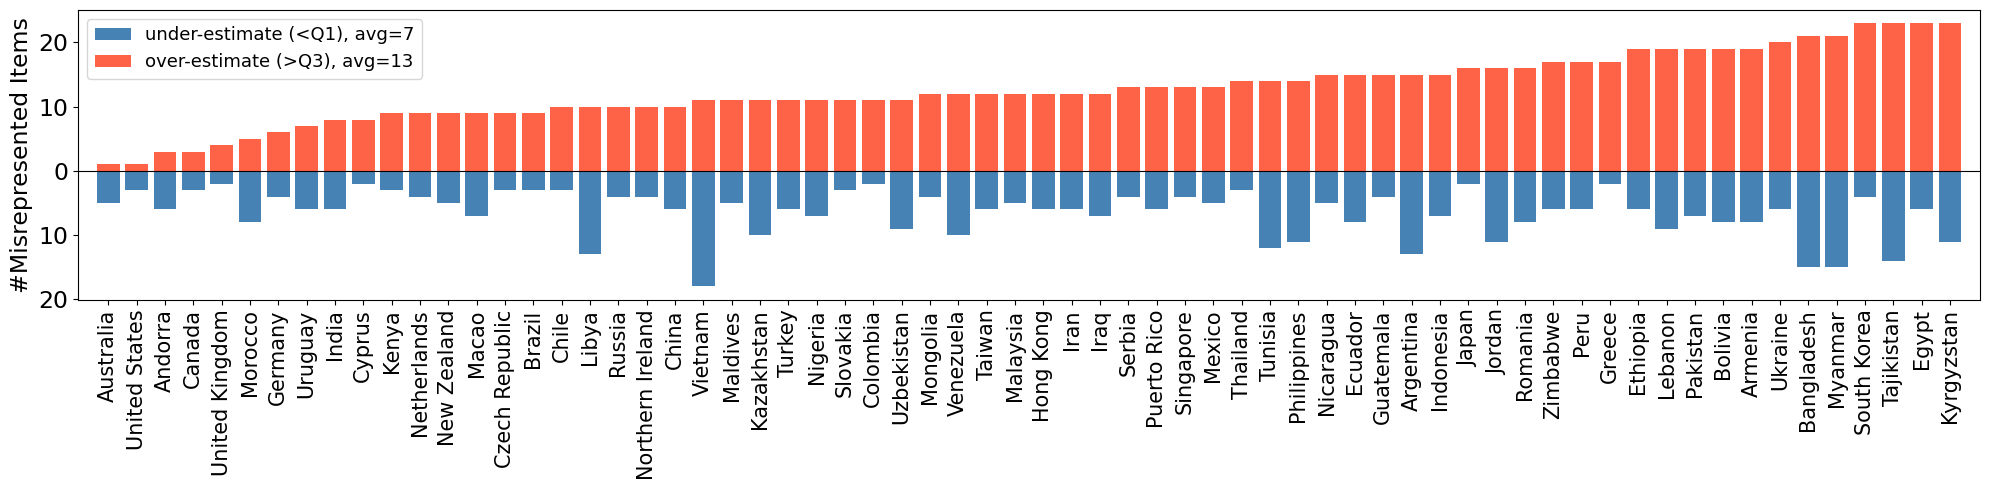

In [12]:
visualize_error_byCtry()

### LLM Misrepresentation VS country GDP
- country error: number of misrepresented items 
- country GDP: from existing data file

In [ ]:
df_GDP_raw = pd.read_csv('./data/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_5358417.csv', index_col=0)
df_eco_raw = pd.read_csv('./data/03-05-23 12_03_18_theglobaleconomy.csv', index_col=0)
df_eco_raw.shape, df_GDP_raw.shape

((7526, 7), (266, 65))

In [17]:
df_GDP_raw.head()

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25609.955720,26515.678080,26942.307980,28421.386490,28451.273740,29326.708060,30220.594520,31650.760540,24487.863560,29342.100860
Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,162.913035,162.551683,172.002460,199.189238,179.387799,198.230368,209.414665,...,1759.182395,1730.394686,1719.183721,1538.552268,1443.692371,1628.586788,1564.734340,1512.270553,1363.540741,1549.772730
Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,62.369375,62.443703,60.950364,82.021738,85.511073,105.243196,143.103233,...,663.141053,651.987862,628.146804,592.476537,520.252064,530.149831,502.056771,500.522664,516.866552,368.754614
Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,106.976475,112.047561,117.730633,122.278715,130.599963,137.186142,142.895375,...,1953.407033,2149.295219,2243.271464,1876.623483,1645.023767,1585.911930,1731.311792,1749.303317,1683.436391,1757.030626
Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4962.552072,5101.983876,5059.080441,3100.830685,1709.515534,2283.214233,2487.500996,2142.238757,1603.993477,1953.533757


In [18]:
df_eco_raw.head()

,Code,ContinentCode,Year,Globalization index (0-100),Economic globalization index (0-100),Political globalization index (0-100),Social globalization index (0-100)
Country,,,,,,,
Afghanistan,AFG,AS,1981,21.04,25.97,24.02,12.00
Afghanistan,AFG,AS,1982,21.45,26.95,24.39,11.89
Afghanistan,AFG,AS,1983,21.94,28.15,24.76,11.84
Afghanistan,AFG,AS,1984,21.73,28.15,24.38,11.68
Afghanistan,AFG,AS,1985,21.68,28.37,24.01,11.78


In [19]:
years = ['2017', '2018', '2019', '2020', '2021']
mask = df_GDP_raw[years].notna().all(axis=1)
df_GDP = df_GDP_raw.loc[mask, ['Country Code']].copy()
df_GDP['GDP_avg'] = df_GDP_raw.loc[mask, years].mean(axis=1).round(3)
df_GDP["log(GDP_avg)"] = np.log(df_GDP['GDP_avg']).round(3)
df_GDP.shape

(245, 3)

In [20]:
eco_cols = df_eco_raw.columns[-4:].tolist()

df_eco_avg = (
    df_eco_raw
    .sort_values('Year')
    .groupby('Country')
    .tail(5)
    .groupby('Country')[eco_cols]
    .mean()
    .dropna()
)
df_eco_avg

,Globalization index (0-100),Economic globalization index (0-100),Political globalization index (0-100),Social globalization index (0-100)
Country,,,,
Afghanistan,38.310,30.400,46.380,35.790
Albania,66.276,67.894,63.522,67.610
Algeria,56.046,36.882,80.082,51.176
Angola,42.408,40.716,51.174,34.816
Antigua and Barbuda,58.004,62.980,34.136,79.248
...,...,...,...,...
Venezuela,52.676,30.908,71.644,55.678
Vietnam,64.530,59.704,73.968,59.930
Yemen,48.742,43.168,65.240,37.452


In [ ]:
base_cols = ['Country Code', 'GDP_avg', 'log(GDP_avg)']
df_GDP = df_GDP[base_cols].join(df_eco_avg, how='inner')
df_GDP

# df_GDP = pd.to_csv('./data/GDP_per_capita.csv')

In [ ]:
df_GDP = pd.read_csv('./data/GDP_per_capita.csv').set_index('Country Name')
df_GDP.head() 

,Country Code,GDP_avg,log(GDP_avg),Globalization index (0-100),Economic globalization index (0-100),Political globalization index (0-100),Social globalization index (0-100)
Country Name,,,,,,,
Aruba,ABW,29005.606,10.275244,45.800,60.764,4.958,84.654
Africa Eastern and Southern,AFE,1523.781,7.328950,NaN,NaN,NaN,NaN
Afghanistan,AFG,483.670,6.181403,38.310,30.400,46.380,35.790
Africa Western and Central,AFW,1701.399,7.439206,NaN,NaN,NaN,NaN
Angola,AGO,2094.096,7.646877,42.408,40.716,51.174,34.816


In [38]:
def organize_error_byCtry(df_outlier, df_GDP): 
    df_error_byCtry = pd.DataFrame({
    'misrepresentation': df_outlier.abs().sum(axis=1),
    'over_estimate': df_outlier.apply(lambda row: row[row > 0].sum(), axis=1),
    'under_estimate': df_outlier.apply(lambda row: abs(row[row < 0].sum()), axis=1),
    }, index=all_countries)
    
    df_GDP = df_GDP.rename(columns={"GDP_avg": "GDP", "log(GDP_avg)": "log(GDP)"})

    df_abr_map = pd.read_csv('../Joshua_40/country_abr_map.csv')

    abr_map = df_abr_map.set_index('country')['abr']
    df_error_byCtry['abr'] = df_error_byCtry.index.map(abr_map)

    extra_cols = ['GDP','log(GDP)', 'Globalization index (0-100)',
                'Economic globalization index (0-100)',
                'Political globalization index (0-100)',
                'Social globalization index (0-100)']

    gdp_by_code = df_GDP.reset_index().set_index('Country Code')[extra_cols]
    df_error_byCtry = (
        df_error_byCtry
        .drop(columns=extra_cols, errors='ignore')
        .join(gdp_by_code, on='abr')
    )

    return df_error_byCtry

In [39]:
df_error_byCtry = organize_error_byCtry(df_error, df_GDP)
df_error_byCtry

,misrepresentation,over_estimate,under_estimate,abr,GDP,log(GDP),Globalization index (0-100),Economic globalization index (0-100),Political globalization index (0-100),Social globalization index (0-100)
Andorra,9,3,6,AND,40841.650,10.617458,NaN,NaN,NaN,NaN
Argentina,28,15,13,ARG,11100.884,9.314780,68.962,43.632,91.206,72.448
Armenia,27,19,8,ARM,4546.961,8.422214,68.130,68.702,69.748,65.742
Australia,6,1,5,AUS,55649.785,10.926833,81.354,67.282,89.100,87.766
Bangladesh,36,21,15,BGD,2118.466,7.658448,50.428,29.582,74.408,47.096
...,...,...,...,...,...,...,...,...,...,...
Uruguay,13,7,6,URY,17677.547,9.780051,73.144,61.110,81.910,76.210
Uzbekistan,20,11,9,UZB,1806.113,7.498932,49.610,47.518,50.582,50.446
Venezuela,22,12,10,VEN,NaN,NaN,NaN,NaN,NaN,NaN
Vietnam,29,11,18,VNM,3418.645,8.137000,64.530,59.704,73.968,59.930


In [40]:
def check_correlation_bymisrep(df, column):
    df_plot = df.dropna(subset=[column])
    print(df_plot.shape)
    # sub_titles = {
    #     'misrepresentation': 'A: All misrepresentation',
    #     'over_estimate':     'B: Over-estimation',
    #     'under_estimate':    'C: Under-estimation',
    # }
    # y_labels = {
    #     'misrepresentation': 'Correctly Represented Items Per Country',
    #     'over_estimate':     '',
    #     'under_estimate':    '',
    # }

    # col = 'misrepresentation'
    df_plot['accuracy'] =  df_avg.shape[1] - df_plot['misrepresentation']
    x, y = df_plot[column], df_plot['accuracy']
    r, p = stats.pearsonr(x, y)


    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x, y, alpha=0.6, s=40)

    slope, intercept, _, _, std_err = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='red', linewidth=1.5)


    n = len(x)
    t_crit = stats.t.ppf(0.975, df=n - 2)
    Sxx = ((x - x.mean())**2).sum()
    se_line = std_err * np.sqrt(Sxx / n + (x_line - x.mean())**2)
    ax.fill_between(x_line, y_line - t_crit * se_line, y_line + t_crit * se_line,
                    color="red", alpha=0.2, linewidth=0)

    ax.set_xlabel("Log (GDP Per Capita)", fontsize=15)
    ax.set_ylabel('Correctly Represented Items Per Country', fontsize=15)
    # ax.set_ylim(0, 40)
    ax.tick_params(axis='both', labelsize=17)

    from matplotlib.lines import Line2D
    p_str = 'p < .001' if p < 0.001 else f'p = {p:.3f}'

    print(f"[{llm_name}] Accuracy ~ {column}")
    print(f"  r={r:.3f}, {p_str}")
    print(f"  slope={slope:.3f}, intercept={intercept:.3f}")
    
    stat_handle = Line2D([0], [0], color="none", label=f"r={r:.3f}\n{p_str}")
    ax.legend(handles=[stat_handle], fontsize=16, loc="upper left", frameon=False)
    ax.set_title(f"{llm_name} Accuracy VS Country GDP", fontsize=17, fontweight="bold", pad=10)
    # plt.savefig('./mainfig/2B_corrGDP_'+llm_name+'.pdf', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show() 


(63, 10)
[GPT] Accuracy ~ log(GDP)
  r=0.647, p < .001
  slope=4.000, intercept=61.644


/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_44792/714773636.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['accuracy'] =  df_avg.shape[1] - df_plot['misrepresentation']


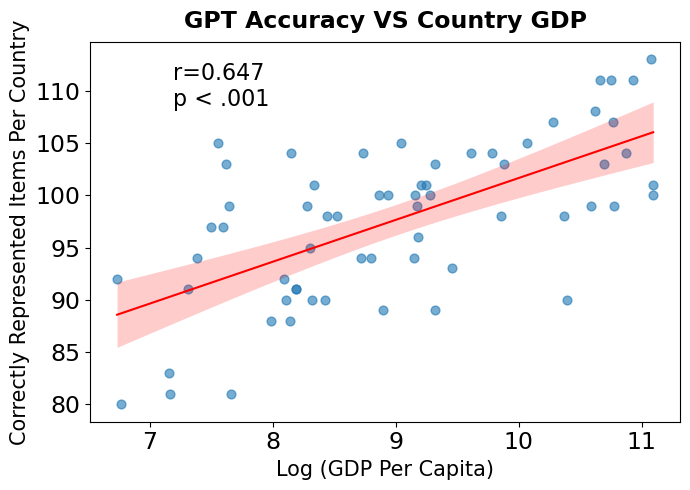

In [ ]:
check_correlation_bymisrep(df_error_byCtry, 'log(GDP)')

### Misrepresentation VS Cultural Distance
- cultural distance from US
- obtained from the paper: https://gwern.net/doc/psychology/2020-muthukrishna.pdf


In [ ]:
with open('./data/culture_dist2US_CHN.pkl', 'rb') as f:
    df_culture_dist = pickle.load(f)

df_culture_dist.head()

,dist2US,dist2CHN
country,,
Algeria,0.138,0.221
Andorra,0.115,0.249
Argentina,0.071,0.150
Armenia,0.154,0.177
Australia,0.035,0.131


In [16]:
def check_correlation_byculture_US(df, df_culture_dist):
    df_plot = df.join(df_culture_dist[["dist2US", "dist2CHN"]], how="inner").dropna(subset=["dist2US", "dist2CHN"])

    col, xlabel = "dist2US", "Cultural Distance to US"

    df_plot['accuracy'] =  df_avg.shape[1] - df_plot['misrepresentation']
    x, y = df_plot[col], df_plot["accuracy"]

    r, p = stats.pearsonr(x, y)
    slope, intercept, _, _, std_err = stats.linregress(x, y)
    n = len(x)

    p_str = "p < .001" if p < 0.001 else f"p = {p:.3f}"
    print(f"[{llm_name}] Accuracy ~ {xlabel}")
    print(f"  n={n}, r={r:.3f}, {p_str}")
    print(f"  slope={slope:.3f}, intercept={intercept:.3f}")

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.scatter(x, y, alpha=0.6, s=40)

    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color="red", linewidth=1.5)

    t_crit = stats.t.ppf(0.975, df=n - 2)
    Sxx = ((x - x.mean())**2).sum()
    se_line = std_err * np.sqrt(Sxx / n + (x_line - x.mean())**2)
    ax.fill_between(x_line, y_line - t_crit * se_line, y_line + t_crit * se_line,
                    color="red", alpha=0.2, linewidth=0)

    ax.set_xlabel(xlabel, fontsize=15)
    ax.set_ylabel("Correctly Represented Items Per Country", fontsize=15)
    # ax.set_ylim(0, 40)
    ax.tick_params(axis="both", labelsize=17)

    from matplotlib.lines import Line2D
    stat_handle = Line2D([0], [0], color="none", label=f"r={r:.3f}\n{p_str}")
    ax.legend(handles=[stat_handle], fontsize=14, loc="upper right", frameon=False)
    ax.set_title(f"{llm_name} Accuracy vs Cultural Distance", fontsize=17, fontweight="bold", pad=10)

    plt.tight_layout()
    # plt.savefig("./mainfig/2B_corrCultureDist2US_"+llm_name+".pdf", dpi=300, bbox_inches="tight")
    plt.show()

[GPT] Accuracy ~ Cultural Distance to US
  n=50, r=-0.627, p < .001
  slope=-93.845, intercept=108.687


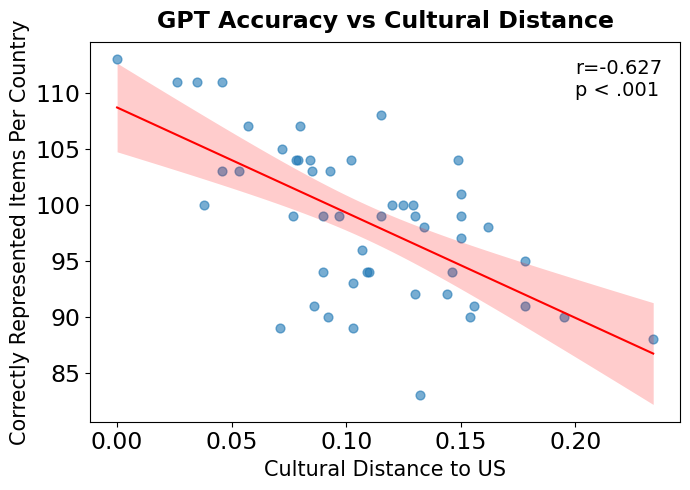

In [15]:
check_correlation_byculture_US(df_error_byCtry, df_culture_dist)

- Fit a linear model: Misrepresent_per_country ~ cultural_distance + gdp

In [42]:
def fit_misrep_md():
    df = df_error_byCtry.join(df_culture_dist[['dist2US']], how='inner')
    
    df['accuracy'] = df_avg.shape[1] - df['misrepresentation']

    # several countries dropped
    df = df.dropna(subset=['accuracy', 'log(GDP)', 'dist2US'])

    df['log_GDP_z']   = zscore(df['log(GDP)'])
    df['dist2US_z']   = zscore(df['dist2US'])

    r, p = pearsonr(df["log_GDP_z"], df["dist2US_z"])
    print(f"Pearson r(log_GDP_z, dist2US_z) = {r:.3f}, p = {p:.3f}")

    model = smf.ols('accuracy ~ log_GDP_z + dist2US_z', data=df).fit()
    print(llm_name)
    print('accuracy ~ log_GDP_z + dist2US_z')
    print(model.summary())
    return model


In [43]:
ln_md = fit_misrep_md()

Pearson r(log_GDP_z, dist2US_z) = -0.696, p = 0.000
GPT
accuracy ~ log_GDP_z + dist2US_z
                            OLS Regression Results                            
Dep. Variable:               accuracy   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.444
Method:                 Least Squares   F-statistic:                     19.78
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           6.87e-07
Time:                        13:45:34   Log-Likelihood:                -146.03
No. Observations:                  48   AIC:                             298.1
Df Residuals:                      45   BIC:                             303.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

### Replicate results for Claude

In [ ]:
# LLM country representation
df_llm = df_claude # df_gpt, df_claude, df_deepseek
llm_name = "Claude" # GPT, Claude, DeepSeek

with open("../data/processed/df_outlier_byIQR_"+llm_name.lower()+".pkl", "rb") as f:
    df_error = pickle.load(f)

df_GDP = pd.read_csv('./data/GDP_per_capita.csv').set_index('Country Name')


In [21]:
df_error_byCtry = organize_error_byCtry(df_error, df_GDP)

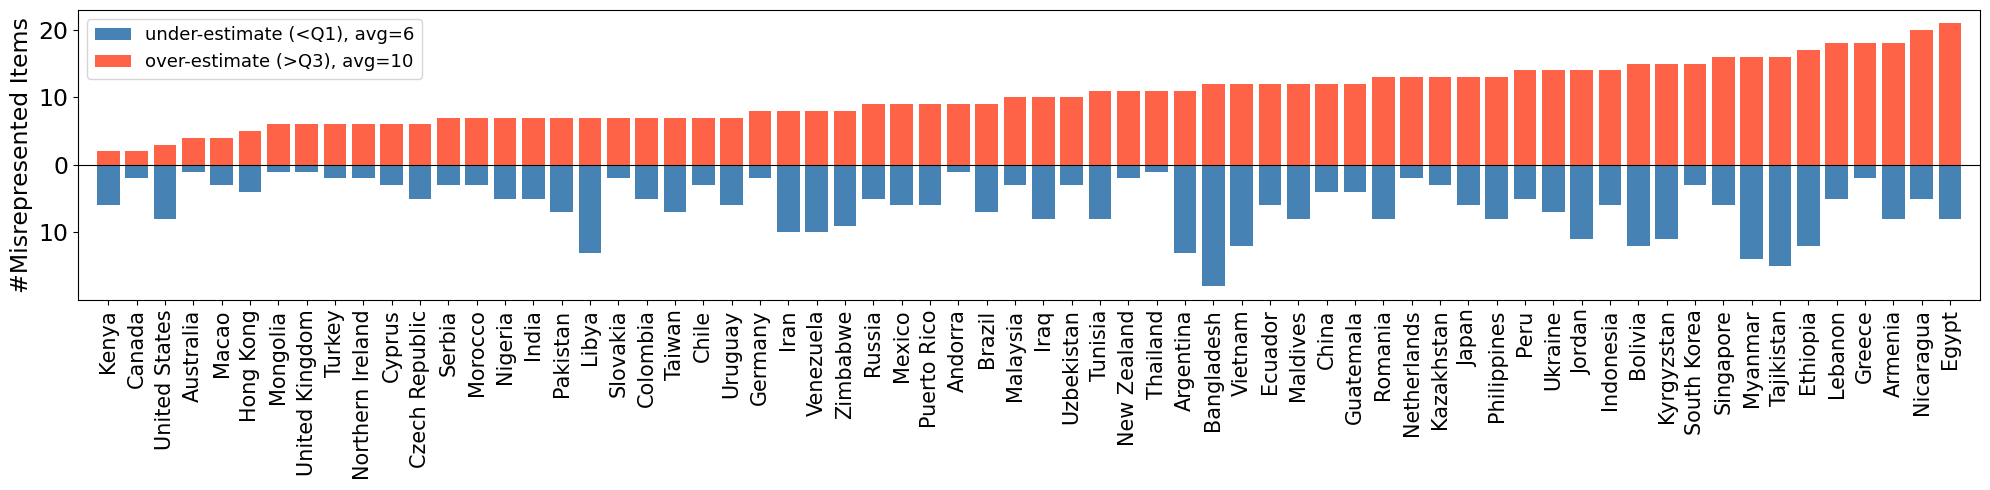

In [22]:
visualize_error_byCtry()

(63, 10)
[Claude] Accuracy ~ log(GDP)
  r=0.544, p < .001
  slope=3.060, intercept=72.863


/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_47713/1640468645.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['accuracy'] =  df_avg.shape[1] - df_plot['misrepresentation']


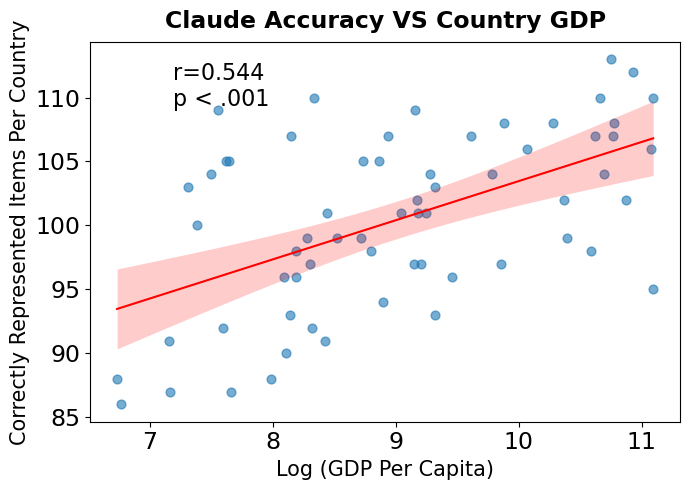

In [23]:
check_correlation_bymisrep(df_error_byCtry, 'log(GDP)')

[Claude] Accuracy ~ Cultural Distance to US
  n=50, r=-0.529, p < .001
  slope=-68.836, intercept=108.614


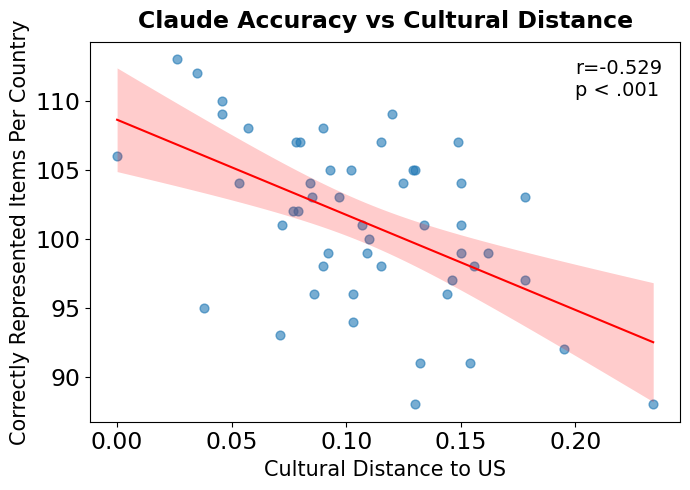

In [24]:
check_correlation_byculture_US(df_error_byCtry, df_culture_dist)

In [22]:
ln_md = fit_misrep_md()

Pearson r(log_GDP_z, dist2US_z) = -0.696, p = 0.000
Claude
accuracy ~ log_GDP_z + dist2US_z
                            OLS Regression Results                            
Dep. Variable:               accuracy   R-squared:                       0.297
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     9.502
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           0.000361
Time:                        13:41:54   Log-Likelihood:                -145.35
No. Observations:                  48   AIC:                             296.7
Df Residuals:                      45   BIC:                             302.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

### Replicate results for DeepSeeK

In [ ]:
# LLM country representation
df_llm = df_deepseek # df_gpt, df_claude, df_deepseek
llm_name = "DeepSeek" # GPT, Claude, DeepSeek

with open("./data/df_outlier_byIQR_"+llm_name.lower()+".pkl", "rb") as f:
    df_error = pickle.load(f)

df_GDP = pd.read_csv('./data/GDP_per_capita.csv').set_index('Country Name')

df_abr_map = pd.read_csv('./data/country_abr_map.csv')


In [24]:
df_error_byCtry = organize_error_byCtry(df_error, df_GDP)

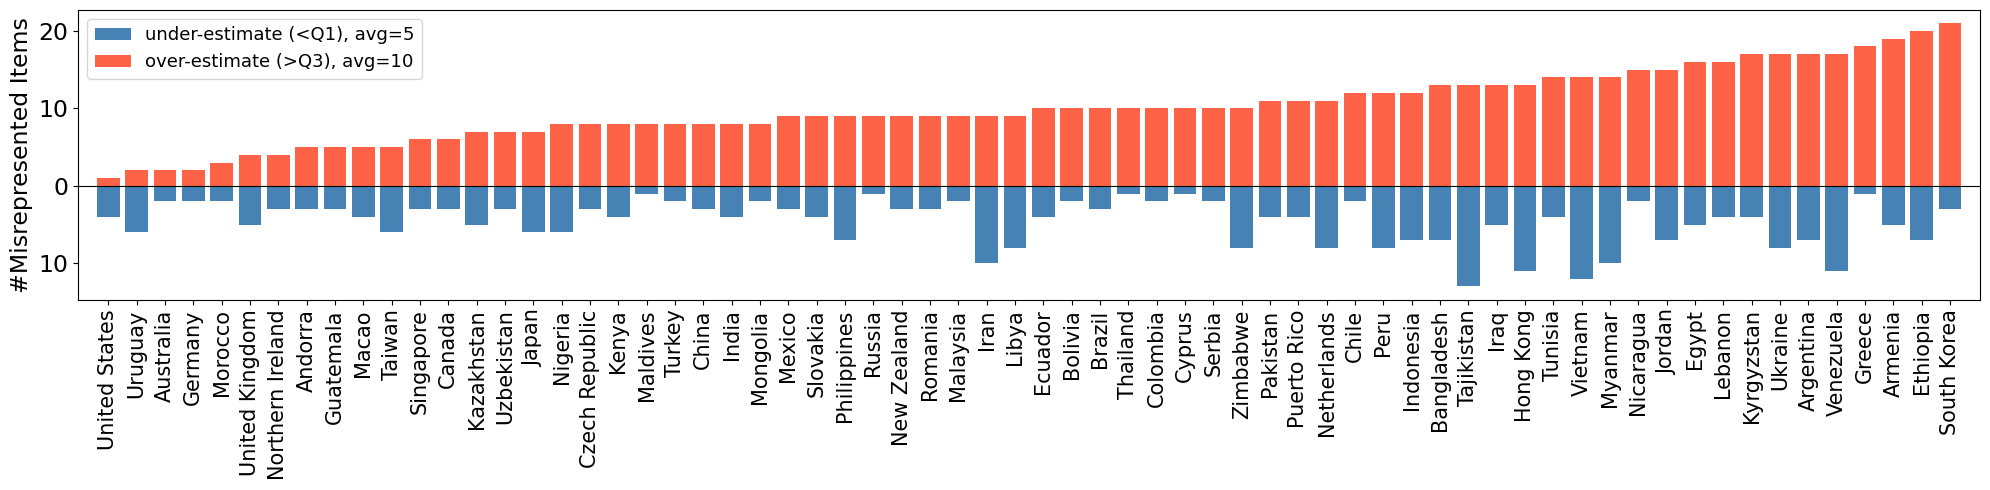

In [27]:
visualize_error_byCtry()

(63, 10)
[DeepSeek] Accuracy ~ log(GDP)
  r=0.464, p < .001
  slope=2.270, intercept=81.780


/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_47713/1640468645.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['accuracy'] =  df_avg.shape[1] - df_plot['misrepresentation']


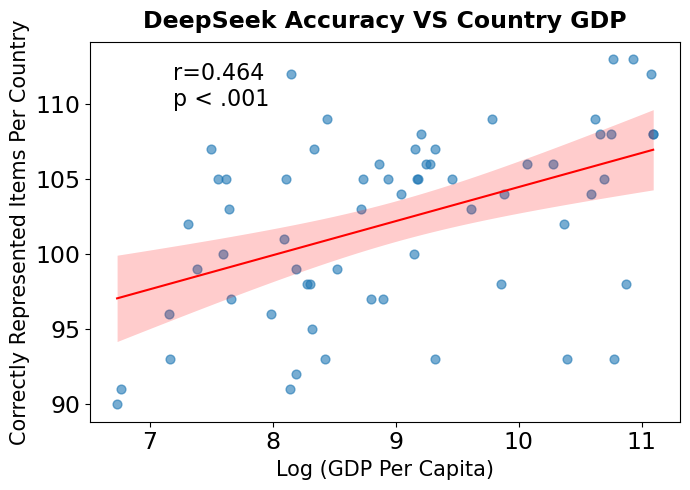

In [28]:
check_correlation_bymisrep(df_error_byCtry, 'log(GDP)')

[DeepSeek] Accuracy ~ Cultural Distance to US
  n=50, r=-0.414, p = 0.003
  slope=-53.903, intercept=108.565


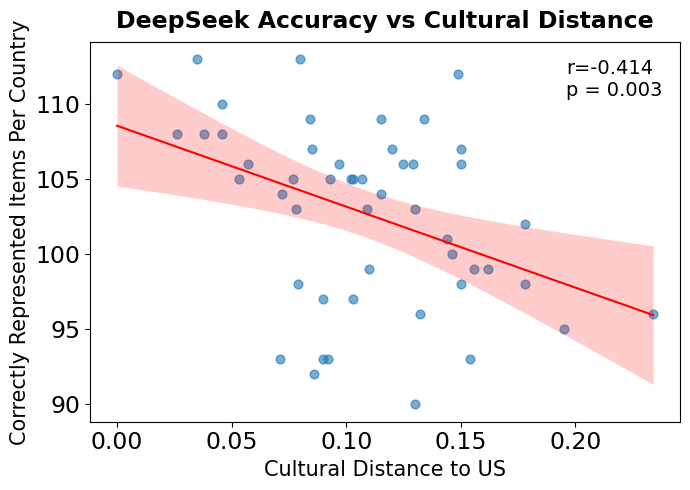

In [29]:
check_correlation_byculture_US(df_error_byCtry, df_culture_dist)

In [25]:
ln_md = fit_misrep_md()

Pearson r(log_GDP_z, dist2US_z) = -0.696, p = 0.000
DeepSeek
accuracy ~ log_GDP_z + dist2US_z
                            OLS Regression Results                            
Dep. Variable:               accuracy   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     5.483
Date:                Sun, 13 Sep 2026   Prob (F-statistic):            0.00740
Time:                        13:42:08   Log-Likelihood:                -148.57
No. Observations:                  48   AIC:                             303.1
Df Residuals:                      45   BIC:                             308.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

------------------------------the end------------------------